# Phase 1 — Lesson 5
# Univariate vs Multivariate Time Series
## EUR/USD H4 Practice Notebook

Default dataset: `Data/EURUSD_H4.csv`

### Objectives
- Understand univariate time series.
- Understand multivariate time series.
- Build both from EUR/USD H4 data.
- Compare variables visually.
- Complete practice exercises and a final task.


## 1. Core idea

**Univariate** = one measured variable over time.

Example:

```python
eurusd[["Close"]]
```

**Multivariate** = two or more measured variables over time.

Example:

```python
eurusd[["Open", "High", "Low", "Close", "Volume"]]
```

Time is the index. We count the measured variables, not the time index.


## 2. Import libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

## 3. Load EUR/USD H4 data

In [2]:
eurusd = pd.read_csv(
    "Data/EURUSD_H4.csv",
    parse_dates=["DateTime"],
    index_col="DateTime"
)

eurusd = eurusd.sort_index()

eurusd.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 20:00:00+00:00,1.39658,1.39945,1.39574,1.39746,57197.00
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39702,38071.80
2009-01-01 04:00:00+00:00,1.39716,1.39740,1.39663,1.39700,67849.25
2009-01-01 08:00:00+00:00,1.39708,1.40370,1.39700,1.40367,128442.75
2009-01-01 12:00:00+00:00,1.40346,1.40707,1.40346,1.40682,128985.65


## 4. Inspect the dataset

In [3]:
print(f"First timestamp: {eurusd.index.min()}")
print(f"Last timestamp : {eurusd.index.max()}")
print(f"Rows           : {len(eurusd):,}")
print(f"Columns        : {list(eurusd.columns)}")
print(f"Index sorted   : {eurusd.index.is_monotonic_increasing}")
print(f"Duplicates     : {eurusd.index.duplicated().sum()}")

First timestamp: 2008-12-31 20:00:00+00:00
Last timestamp : 2026-09-01 20:00:00+00:00
Rows           : 30,561
Columns        : ['Open', 'High', 'Low', 'Close', 'Volume']
Index sorted   : True
Duplicates     : 0


# Part 1 — Univariate Time Series

A univariate time series contains one variable measured through time.

For EUR/USD, `Close` alone is a univariate time series.


In [4]:
eurusd_close = eurusd[["Close"]]

eurusd_close.head()

,Close
DateTime,
2008-12-31 20:00:00+00:00,1.39746
2009-01-01 00:00:00+00:00,1.39702
2009-01-01 04:00:00+00:00,1.39700
2009-01-01 08:00:00+00:00,1.40367
2009-01-01 12:00:00+00:00,1.40682


## 5. Plot Close only

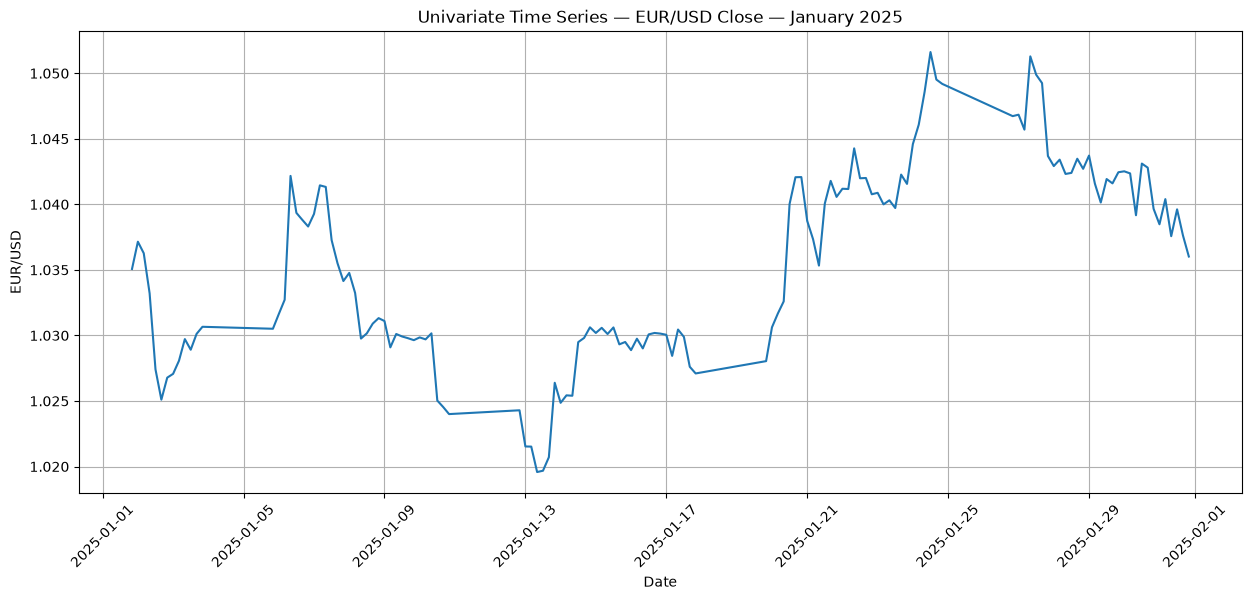

In [8]:
close_january = eurusd_close.loc["2025-01"]

plt.figure(figsize=(15, 6))
plt.plot(close_january.index, close_january["Close"])
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("Univariate Time Series — EUR/USD Close — January 2025")
plt.xticks(rotation=45)
plt.grid()
plt.show()

This is univariate because only one measured variable is being analyzed: `Close`.


# Part 2 — Multivariate Time Series

A multivariate time series contains two or more variables measured at the same timestamps.


In [9]:
eurusd_multi = eurusd[
    ["Open", "High", "Low", "Close", "Volume"]
]

eurusd_multi.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 20:00:00+00:00,1.39658,1.39945,1.39574,1.39746,57197.00
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39702,38071.80
2009-01-01 04:00:00+00:00,1.39716,1.39740,1.39663,1.39700,67849.25
2009-01-01 08:00:00+00:00,1.39708,1.40370,1.39700,1.40367,128442.75
2009-01-01 12:00:00+00:00,1.40346,1.40707,1.40346,1.40682,128985.65


## 6. Open vs Close

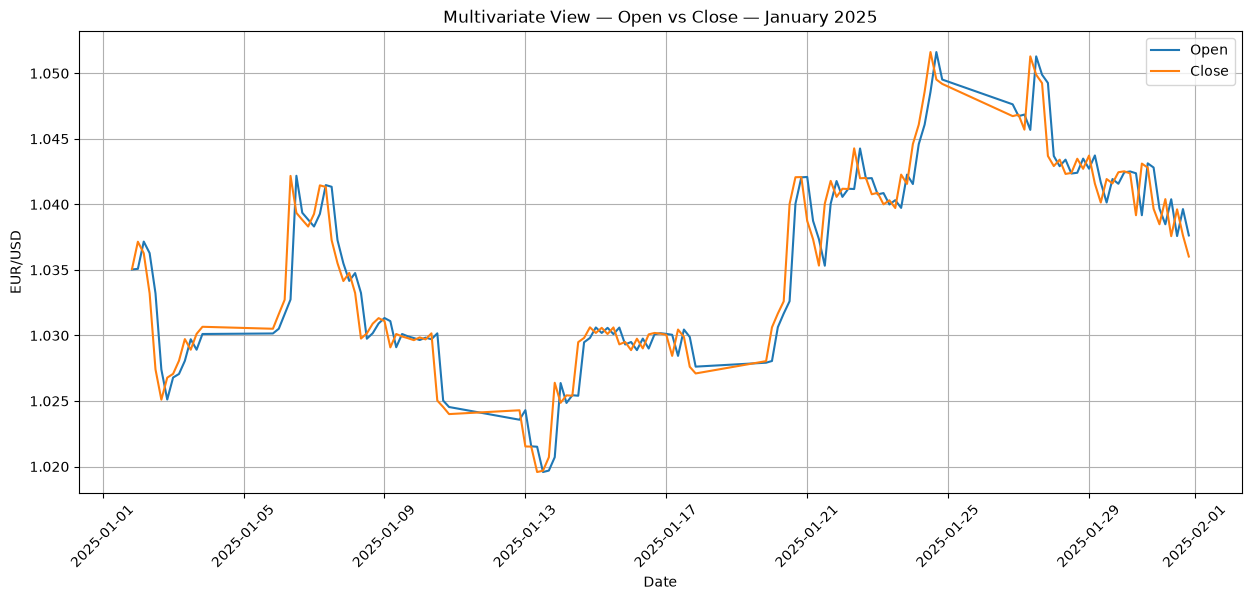

In [10]:
january_multi = eurusd_multi.loc["2025-01"]

plt.figure(figsize=(15, 6))
plt.plot(january_multi.index, january_multi["Open"], label="Open")
plt.plot(january_multi.index, january_multi["Close"], label="Close")
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("Multivariate View — Open vs Close — January 2025")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

## 7. High vs Low

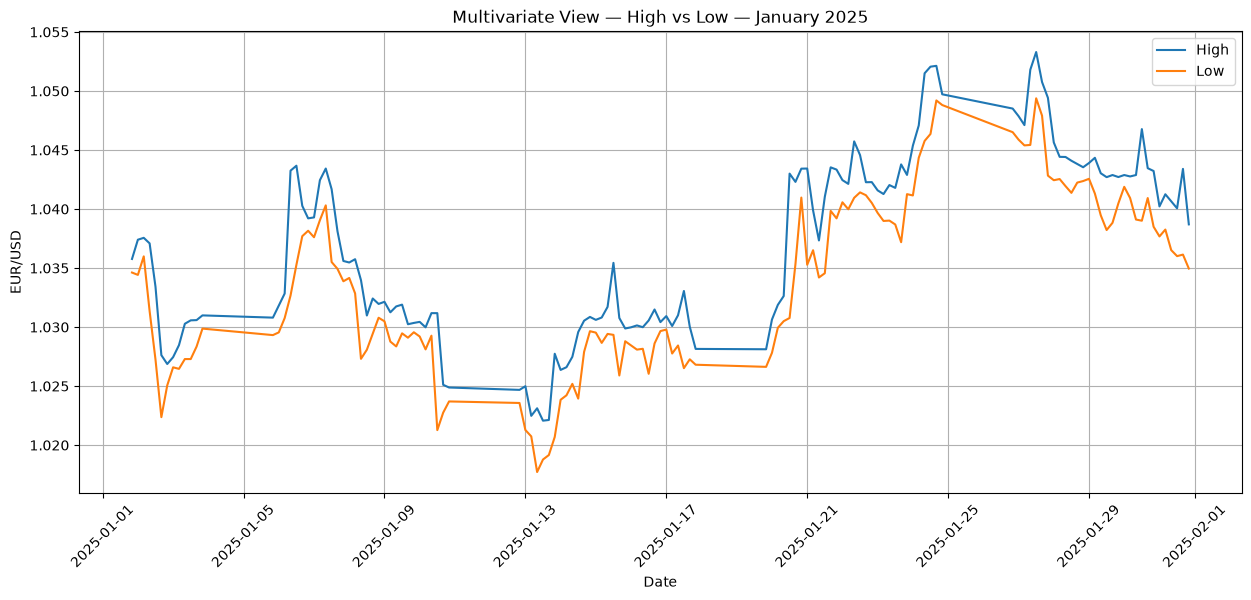

In [11]:
plt.figure(figsize=(15, 6))
plt.plot(january_multi.index, january_multi["High"], label="High")
plt.plot(january_multi.index, january_multi["Low"], label="Low")
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("Multivariate View — High vs Low — January 2025")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

## 8. OHLC together

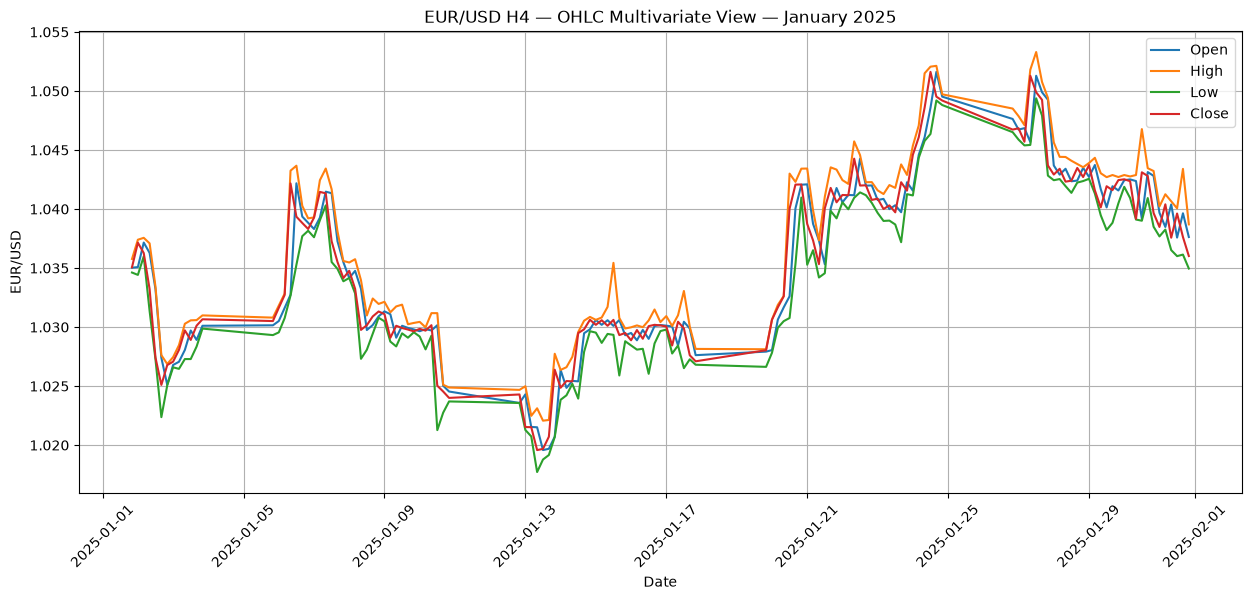

In [12]:
plt.figure(figsize=(15, 6))
plt.plot(january_multi.index, january_multi["Open"], label="Open")
plt.plot(january_multi.index, january_multi["High"], label="High")
plt.plot(january_multi.index, january_multi["Low"], label="Low")
plt.plot(january_multi.index, january_multi["Close"], label="Close")
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 — OHLC Multivariate View — January 2025")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

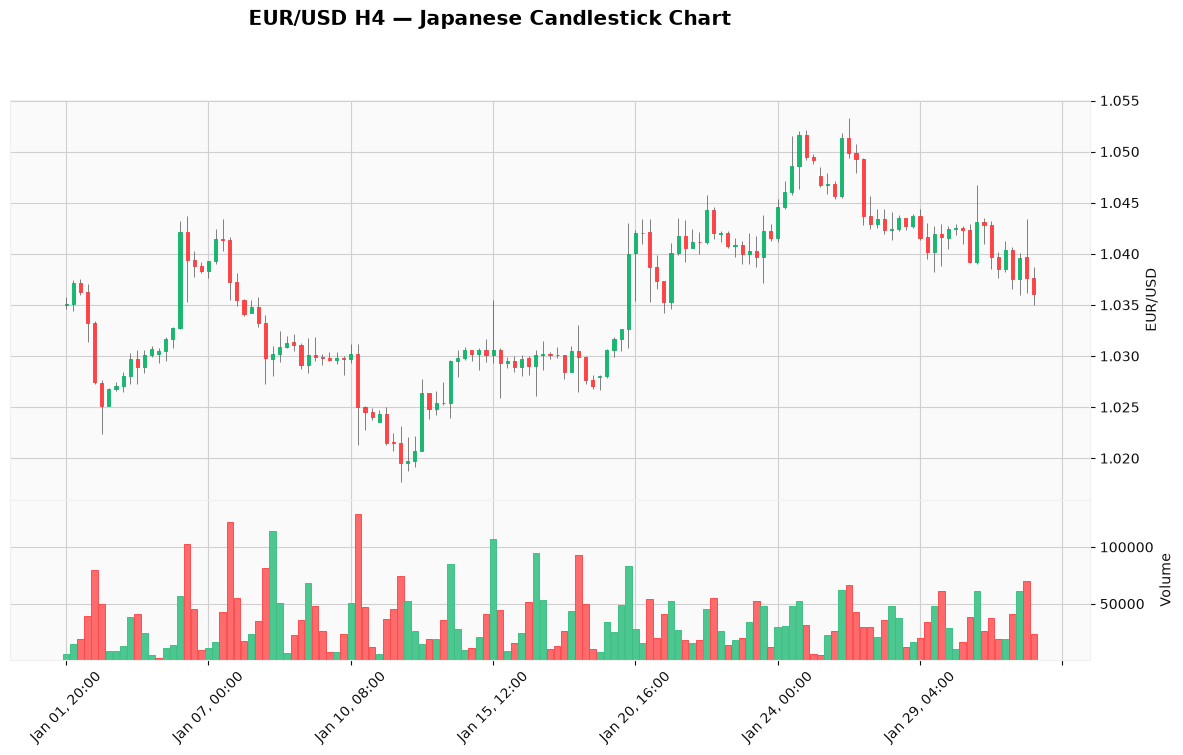

In [15]:
mpf.plot(
    january_multi,
    type="candle",
    style="yahoo",
    title="EUR/USD H4 — Japanese Candlestick Chart",
    ylabel="EUR/USD",
    volume=True,
    ylabel_lower="Volume",
    figsize=(15, 8)
)

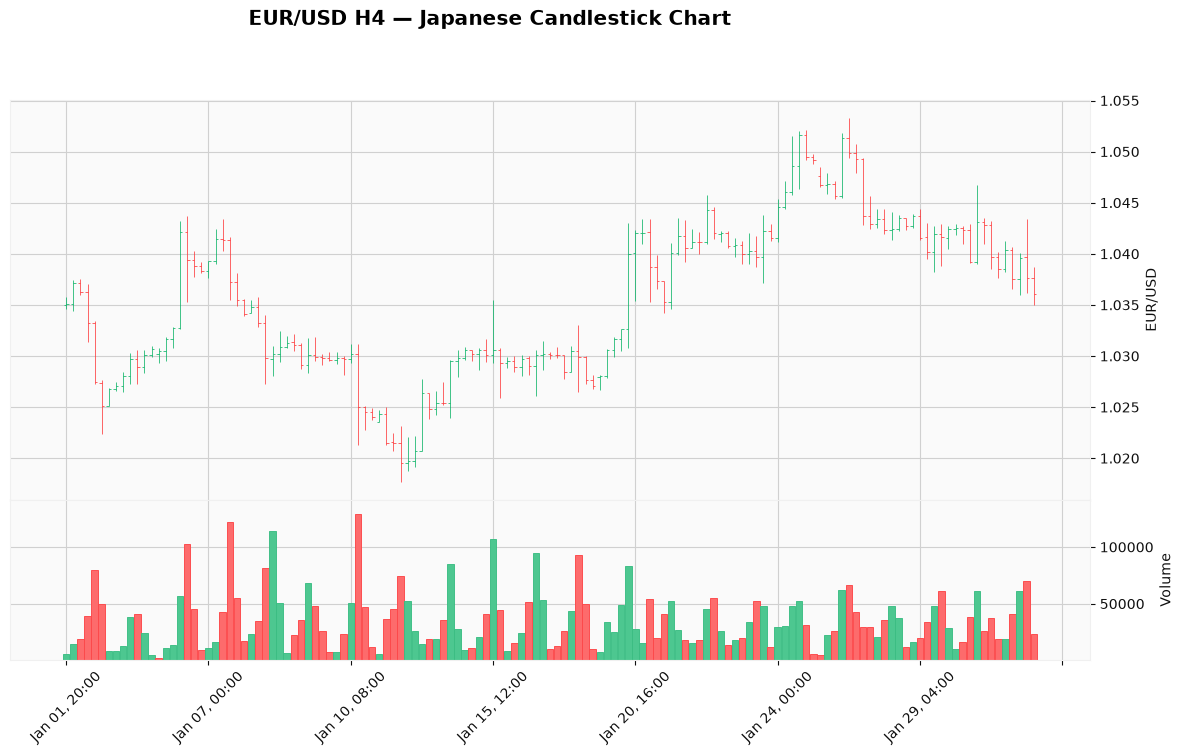

In [16]:
mpf.plot(
    january_multi,
    # type="candle",
    style="yahoo",
    title="EUR/USD H4 — Japanese Candlestick Chart",
    ylabel="EUR/USD",
    volume=True,
    ylabel_lower="Volume",
    figsize=(15, 8)
)

More variables can provide more information, but they also make the analysis more complex. Multivariate does not automatically mean better.


## 9. Plot Volume separately

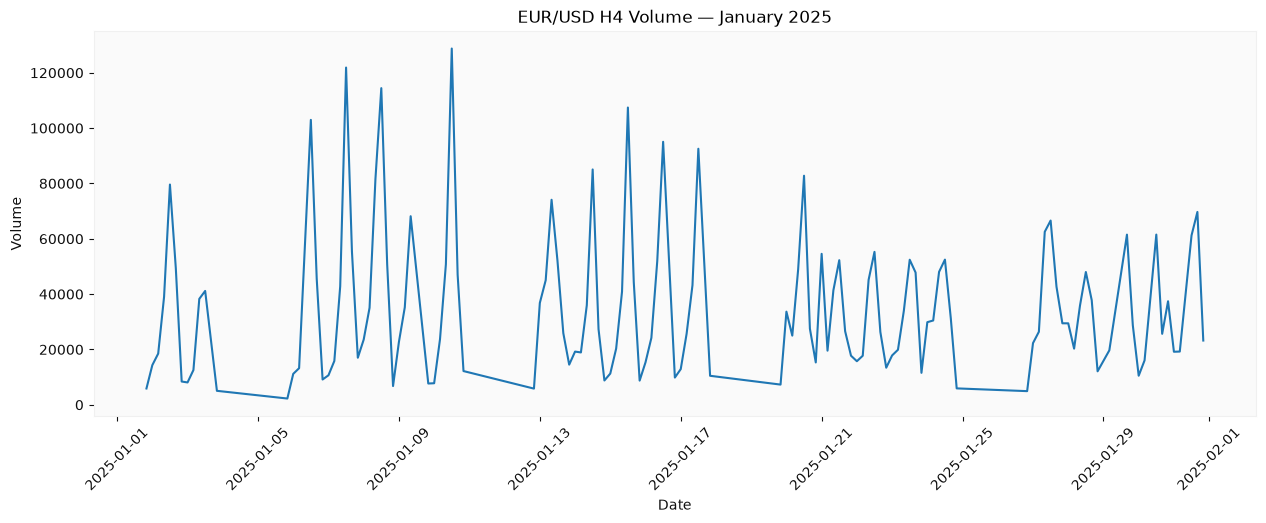

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(january_multi.index, january_multi["Volume"])
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("EUR/USD H4 Volume — January 2025")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Volume is usually better on a separate chart because it uses a very different scale from EUR/USD prices.


## 10. Derived variables

In [18]:
eurusd["Range"] = eurusd["High"] - eurusd["Low"]

eurusd[["High", "Low", "Range"]].head()

,High,Low,Range
DateTime,,,
2008-12-31 20:00:00+00:00,1.39945,1.39574,0.00371
2009-01-01 00:00:00+00:00,1.39754,1.39672,0.00082
2009-01-01 04:00:00+00:00,1.39740,1.39663,0.00077
2009-01-01 08:00:00+00:00,1.40370,1.39700,0.00670
2009-01-01 12:00:00+00:00,1.40707,1.40346,0.00361


If you analyze only `Range`, that is still univariate.

```python
eurusd[["Range"]]
```

If you analyze `Close` and `Range`, that is multivariate.

```python
eurusd[["Close", "Range"]]
```


# Practice Exercises

## Exercise 1 — Identify the type

Decide whether each is univariate or multivariate:

A:
```python
eurusd[["Close"]]
```

B:
```python
eurusd[["Open", "Close"]]
```

C:
```python
eurusd[["High", "Low", "Volume"]]
```

D:
```python
eurusd[["Range"]]
```


### Your answers

A:  

B:  

C:  

D:  


## Exercise 2 — Univariate

Using March 2025:
1. select only `Close`,
2. display the first rows,
3. plot it.


In [ ]:
# Write your Exercise 2 code here


## Exercise 3 — Multivariate

Using March 2025, select:
- Open
- High
- Low
- Close

Display the first 10 rows.


In [ ]:
# Write your Exercise 3 code here


## Exercise 4 — Open vs Close

For March 2025:
1. plot Open,
2. plot Close,
3. put both on the same chart,
4. add a legend,
5. explain why the chart is multivariate.


In [ ]:
# Write your Exercise 4 code here


## Exercise 5 — High vs Low

For March 2025:
1. plot High,
2. plot Low,
3. put them on the same chart,
4. add legend and grid.


In [ ]:
# Write your Exercise 5 code here


# Final Practice Task

Choose one month in 2025.

### Part 1 — Univariate
Create a DataFrame containing only `Close`, display it, and plot it.

### Part 2 — Multivariate
Create a DataFrame containing:
- Open
- High
- Low
- Close
- Volume

Then:
- display the first rows,
- plot Open vs Close,
- plot High vs Low,
- plot Volume separately.

### Part 3 — Write short answers
1. What information do you get from Close alone?
2. What extra information do Open, High, and Low provide?
3. Why is Volume better plotted separately?
4. Which is simpler: univariate or multivariate?
5. Does multivariate always mean better?


In [ ]:
# Final Practice Task

# Example:
# practice_month = eurusd.loc["2025-03"]

practice_month = eurusd.loc["2025-__"]

# PART 1 — UNIVARIATE


# PART 2 — MULTIVARIATE




# Lesson 5 Cheat Sheet

## Univariate
One variable measured over time.

```python
eurusd_close = eurusd[["Close"]]
```

## Multivariate
Two or more variables measured over time.

```python
eurusd_multi = eurusd[
    ["Open", "High", "Low", "Close", "Volume"]
]
```

## Remember
- Time is the index.
- We count measured variables, not the index.
- More variables can add information.
- More variables also add complexity.
- Multivariate does not automatically mean better.
